# Lesson 112 · OGB reproduction: defend a full GCN experiment

Executed solution · Three live TODOs and independent CHECKs. Submission requires the written EXIT.

In [1]:
# Install missing dependencies first, then restart the kernel if needed:
# %pip install torch==2.8.0 ogb==1.3.6 numpy==2.2.6 pandas==2.3.2 scikit-learn==1.7.1
import sys, importlib.metadata
print('Python',sys.version)
print({k:importlib.metadata.version(k) for k in ['torch','numpy','pandas','ogb']})


Python 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'torch': '2.13.0+cpu', 'numpy': '2.5.0', 'pandas': '3.0.3', 'ogb': '1.3.6'}


## Runtime and data

The GPU author runtime pins Python 3.12, torch 2.8.0, NumPy 2.2.6, pandas 2.3.2, OGB 1.3.6, and scikit-learn 1.7.1. Source parity also uses torch-geometric 2.6.1. The local CPU execution records its own installed versions. The archive is about 80 MiB and checked by SHA-256. Allow 4 GiB RAM for the notebook and more time on CPU. All model/training code is visible below. Live Colab is NOT_CHECKED. Full training is off by default; the default run performs two complete-graph epochs.

<p class="stream-kicker">One claim · one frozen protocol · ten fresh fits</p>

Your tangible win is to **reproduce and defend one published OGB result**: a full-batch GCN on `ogbn-arxiv`. By the end you should be able to trace one prediction, explain which information entered training, and decide whether the resulting ten-run mean supports a bounded reproduction claim.

Read sections 1–5 in about 25 minutes; then work through the three live notebook tasks. Full training is a separate compute session. Author execution does not establish your mastery: **PENDING_WRITTEN_DEFENSE** until you submit the EXIT explanation.

[Student notebook](https://avistian.github.io/relational/labs/0112-ogb-gcn-reproduction.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/solutions/0112-ogb-gcn-reproduction.ipynb) · [Readable lab](https://avistian.github.io/relational/labs/html/0112-ogb-gcn-reproduction.html) · [Reference](https://avistian.github.io/relational/reference/ogb-reproduction.html) · [Exact reproduction protocol](https://avistian.github.io/relational/labs/l112-reproduction.md)



## 1 · Start from the question, before the score

Imagine that a colleague hands you a test accuracy of 71.9%. Is this a reproduction? You cannot tell yet. The number needs an identity: dataset bytes, split indices, model, optimization schedule, selection rule, and aggregation across runs. Two equal scores can come from different experiments.

The named target is **Hu et al., OGB, Table 6, GCN on ogbn-arxiv**: test accuracy **71.74 ± 0.29%**, validation **73.00 ± 0.17%**. The original graph is made undirected for this baseline. Read [§4.3 and Table 6](https://arxiv.org/html/2005.00687v6#S4.SS3) first; consult the [released implementation](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/examples/nodeproppred/arxiv/gnn.py) for the operational settings.

We freeze a **0.5 percentage-point absolute gap in the mean** as our descriptive closeness threshold before the runs. A 72.10% mean would be CLOSE because the gap is 0.36 pp. A 72.40% mean would be OUTSIDE_TOLERANCE even though it is higher. This is a reproduction criterion, not a significance or equivalence test. We compare variability separately rather than forcing the new standard deviation to equal the historical one.

**Retrieve before continuing:** what went wrong in lesson 110 if weights were restored without all the relevant state? For this static GCN, there is no event memory, but batch-normalization running means and variances are still part of the selected state. Reusing only the selected linear weights would define a different predictor.



## 2 · Time splits and information visibility are separate decisions

The release contains 169,343 papers, 128 features per paper, and 40 target classes. Its official year split has **90,941 train**, **29,799 validation**, and **48,603 test** nodes. Training labels come from papers through 2017, validation from 2018, and test from 2019 onward. Use the official index files rather than creating another split. See the [OGB dataset specification](https://ogb.stanford.edu/docs/nodeprop/#ogbn-arxiv).

This is a transductive full-graph baseline. All nodes' features and the complete released citation structure enter propagation. Only training labels enter the objective. Validation labels select an epoch; test labels score that selected predictor. Batch normalization also sees hidden features from all nodes during fitting. The released `gnn.py` runs the model on `data.x` and the full symmetric adjacency before indexing the training loss.

That distinction connects directly to [lesson 109's database timestamp contract](https://avistian.github.io/relational/lessons/0109-database-timestamp-contracts.html) and [lesson 110's temporal checkpoint](https://avistian.github.io/relational/lessons/0110-temporal-gnn-checkpoint.html). A time-based **label split** does not imply a time-filtered **feature graph**. This baseline answers the benchmark's transductive question. To answer “what could a deployed model have known in 2017?”, we would need another visibility contract, features available at that date, and a separately reported experiment.

<figure class="stream-figure" tabindex="0">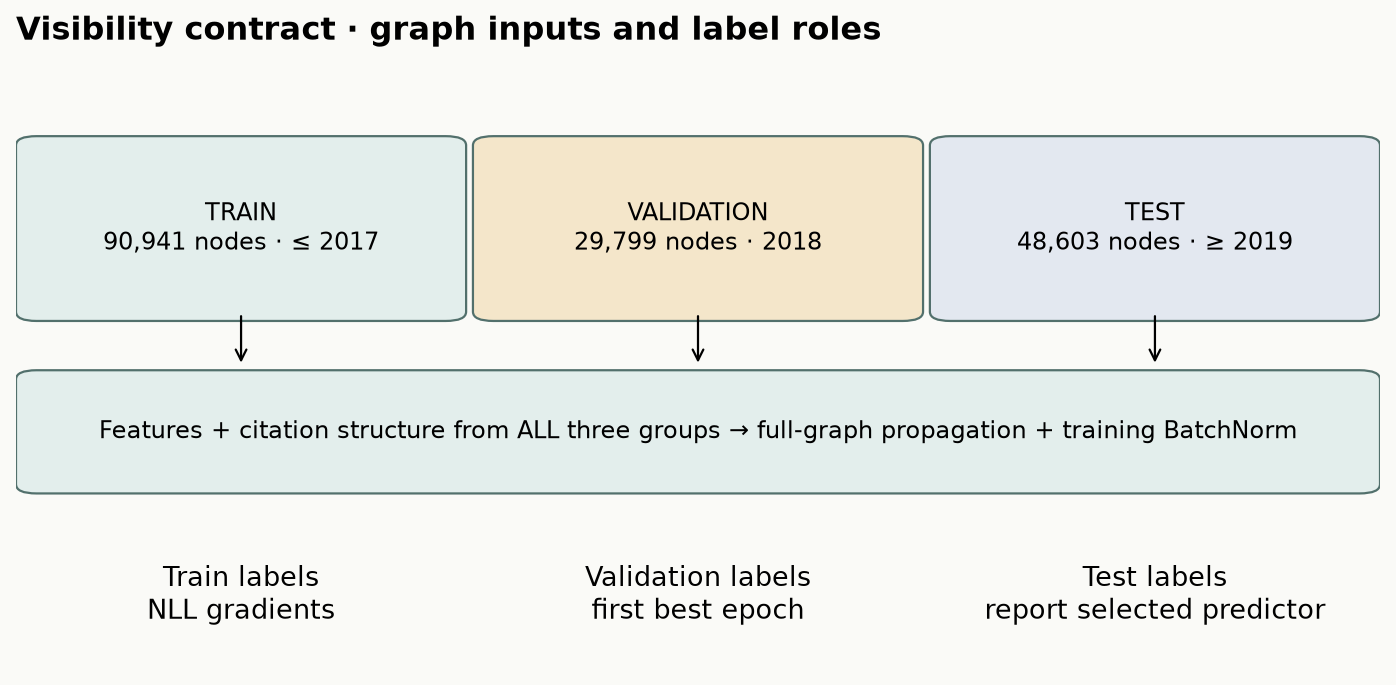<figcaption>Official year-based label split; all feature rows and citation edges are visible to the transductive baseline.</figcaption></figure>

**Predict:** if you change a test label, should the next training gradient change? No. If you change a test node's features, can a training node's representation change? Yes: there may be a message-passing path, and batch normalization couples node activations. Label masking protects the objective; it does not remove held-out nodes from the computation.



## 3 · Model architecture: follow a paper to its prediction

<figure class="stream-figure" tabindex="0">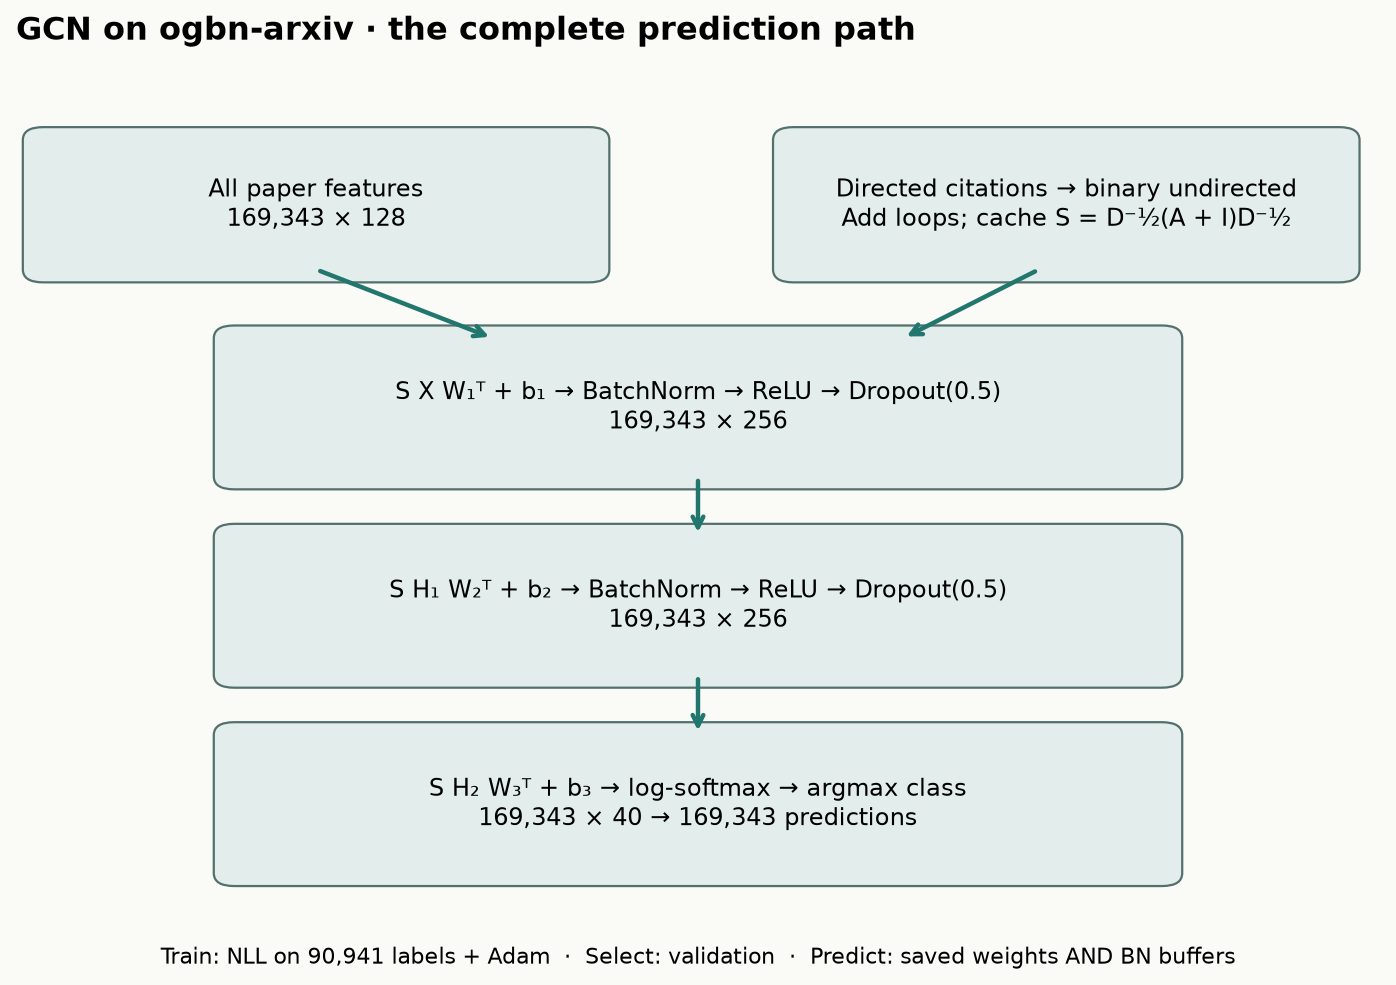<figcaption>Every layer and shape in the complete 110,120-parameter GCN. Training masks the labels, not the feature graph.</figcaption></figure>

Start with the feature matrix **X ∈ R^(169343×128)**. Turn the directed citations into a binary undirected adjacency, remove duplicate relations, and add one self-loop per node. This operation changes the information flow: a cited paper and a citing paper can now both send messages. It is part of the released baseline's definition.

Let Ã = A + I after deduplication, dᵢ = Σⱼ Ãᵢⱼ, and Sᵢⱼ = Ãᵢⱼ / √(dᵢdⱼ). One convolution is:

**Z = S H Wᵀ + b**.

Our weight is stored as `[output channels, input channels]`, hence the transpose. Each receiver i adds transformed messages from neighbors j, including itself, scaled by their degrees. The bias is added **after** aggregation. An isolated node has dᵢ = 1 and sends its own features unchanged through S; it still receives the learned linear transformation.

The first two convolutions are followed by batch normalization, ReLU, and 50% dropout. The third maps to 40 class logits, followed by log-softmax. Training uses negative log-likelihood on training nodes, with one full-graph Adam step per epoch. Evaluation turns dropout off and uses the stored batch-normalization statistics. The final predicted class is the largest log-probability.

The complete path is **128 → 256 → 256 → 40**, with **110,120 trainable parameters**. These details follow the pinned [GCN class and training defaults](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/examples/nodeproppred/arxiv/gnn.py#L13). The visible lab exposes the sparse multiplication, normalization, model, optimizer loop and checkpoint selection; there is no hidden model service.

### Work one propagation step by hand

Take a chain 0—1—2 with scalar features `[2, 4, 8]`. After self-loops, degrees are `[2, 3, 2]`. Before a learned transform, the middle node becomes:

**h′₁ = 2/√6 + 4/3 + 8/√6 ≈ 5.416**.

This is not a simple neighbor mean. The central coefficient is 1/3 and endpoint coefficients are 1/√6. If both 0→1 and 1→0 occur in the raw citations, treating the concatenated edge list as a multigraph would alter degrees and messages. Task 1 catches that error with duplicate, reciprocal, self-loop and isolated-node fixtures.

Implement `normalized_adjacency` in the live task below.

**Task 1 · TODO → CHECK:** implement `normalized_adjacency`. The independent dense oracle checks both its values and gradients through a feature matrix. Explain why reversing every raw edge and merely summing duplicates is insufficient.



## 4 · Mask the objective, then select one whole predictor

Once messages reach the output, we need to decide which answers may teach the model. The model produces a score for every node, but the objective indexes only `train_idx`:

Implement `training_loss` in the live task below.

**Task 2 · TODO → CHECK:** implement `training_loss`. The check changes every held-out label and demands the same loss; held-out output rows must receive zero loss gradient. Upstream features can still receive gradients through graph connectivity. Do not confuse these two statements.

Every run lasts **500 epochs**. Adam uses learning rate **0.01**, with the library defaults for its other settings. After each update we evaluate validation accuracy. When it strictly improves, save the whole `state_dict`, including the two batch-normalization layers' running buffers. If epochs tie, retain the **first** maximum, matching the released logger's `argmax`. At the end, restore that state and evaluate its predictions.

Implement `selected_epoch` in the live task below.

**Task 3 · TODO → CHECK:** implement `selected_epoch`. Try validation `[0.60, 0.80, 0.70, 0.80]`: the zero-based answer is 1. The function takes no test score, so it cannot legitimately choose by test performance. The full runner checks that restored predictions reproduce the selected epoch's metrics.

**Predict before revealing the worked example:** which epoch is selected, and which test score is reportable?

<details open><summary>Worked selection example and no-JavaScript fallback</summary><p>Suppose validation accuracies are 72.0, 73.0, 72.8, 73.0, 72.9% and test accuracies are 71.0, 71.6, 72.2, 71.8, 72.0%. Select epoch 2, the first validation maximum, and report its test score 71.6%. Selecting epoch 3 by test gives 72.2% but uses the test set to make a training decision. The apparent 0.6 pp improvement does not measure better generalization.</p></details>

The released training script logs test scores every epoch, but its logger selects by validation. Our runner preserves that behavior and freezes all choices before the full run. Test traces are retained as audit evidence, not as a reason to adjust the model or rerun favorable seeds. A safer new research implementation could defer test evaluation until selection; that would need its own recorded protocol.



## 5 · Reproduce the distribution, not a lucky seed

Fix seeds 0–9 and run all ten complete schedules. Each seed starts with fresh parameters and optimizer state. We retain every run, even one with disappointing accuracy. Seed 100 is reserved for the timed pilot and is excluded from the published-target comparison.

For the ten test accuracies a₁,…,a₁₀ in percent, report mean **ā = Σaᵢ/10** and sample seed standard deviation **s = √[Σ(aᵢ−ā)²/9]**. The ± bar describes variability among seeds on this fixed dataset. It is not automatically a confidence interval over new datasets, and ten seeds do not test ten independent graphs.

**Author-reference results, separate from your current notebook execution.**

| Population | Mean accuracy | Sample seed SD | Published mean | Gap | Verdict |
|---|---:|---:|---:|---:|---|
| valid | 73.1041% | 0.0977 pp | 73.00% | +0.1041 pp | CLOSE |
| test | 71.8480% | 0.3119 pp | 71.74% | +0.1080 pp | CLOSE |

Completed **10 fresh runs × 500 epochs = 5,000 epochs**. Independent metrics cover all 169,343 node predictions per seed. Successful pilot plus full-run resource estimate: **USD0.2087**; the failed pre-training checker attempt and startup/build/storage overhead are unitemized, covered by the conservative budget reserve. Historical identity and full-paper parity remain NOT_ESTABLISHED. [Machine-readable evidence](https://avistian.github.io/relational/labs/evidence/l112/summary.json).

<figure class="stream-figure" tabindex="0">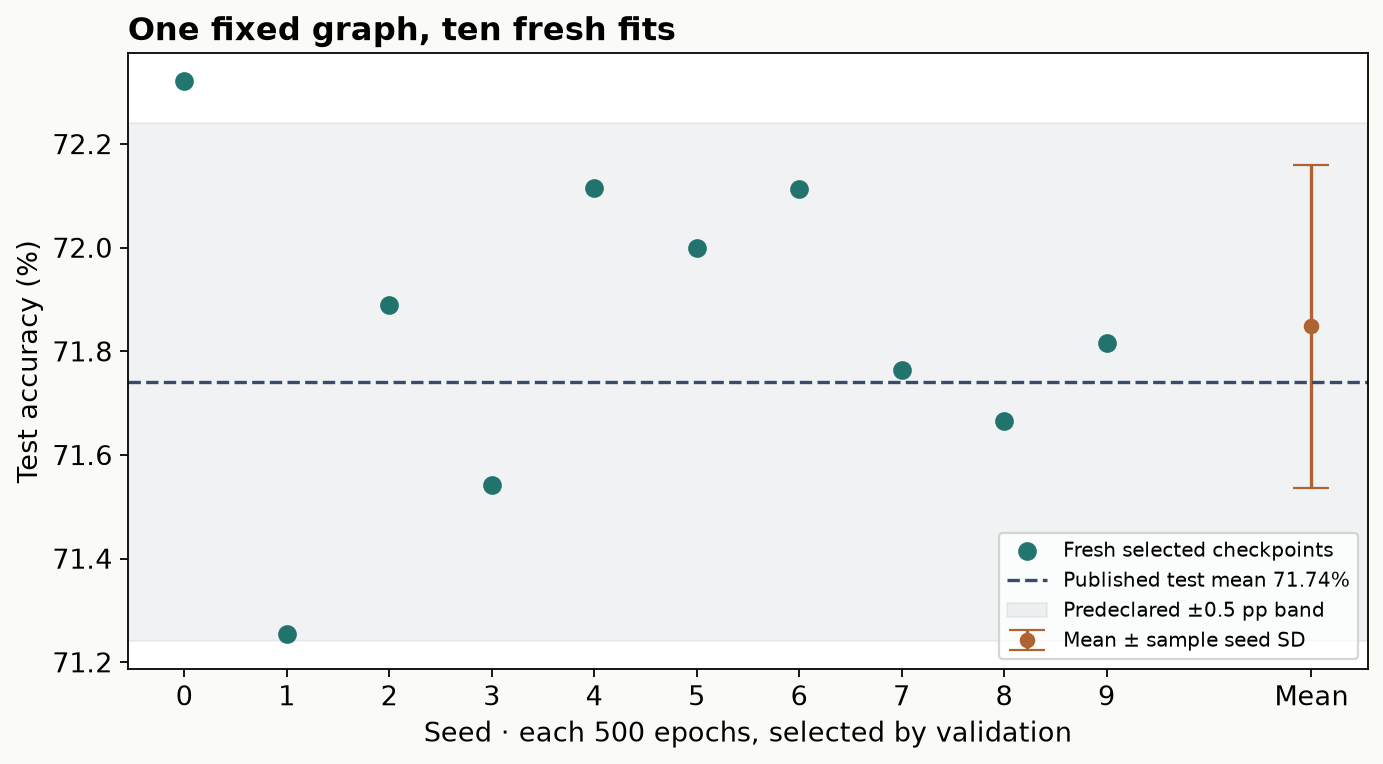<figcaption>Full-data author runs: individual seeds, mean and sample seed SD. The shaded target band is a descriptive predeclared tolerance.</figcaption></figure>

Read the dots before the mean. Then compare the mean to the predeclared target and tolerance. Finally inspect the protocol and deviations. A close number plus a different visibility policy is not a faithful reproduction; an outside-tolerance result with a careful audit is still useful scientific evidence.



## 6 · What the evidence establishes

The [protocol ledger](https://avistian.github.io/relational/labs/l112-reproduction.md) names the data hash, pinned source revision, exact environment and commands. The author checks independently reconstruct accuracy from saved node-level predictions and compare the visible implementation with the original model using identical parameters. Forward/gradient agreement and full checkpoint replay test implementation fidelity. They do not establish that the original historical seeds or hardware have been recovered.

Our explicit deviations are a native PyTorch sparse-CSR operator instead of the release's `torch_sparse` representation; separately seeded runs instead of an unseeded sequence of resets; a current pinned runtime; and a custom raw reader whose arrays are checked against the official OGB loader. All affect what “reproduction” can honestly mean. Historical bitwise identity and reproduction of the entire OGB paper remain **NOT_ESTABLISHED**.

There is no hyperparameter search in this lesson: it replays the selected published baseline. Other OGB datasets, link tasks, alternative GNNs, and the paper's original tuning procedure are outside this selected experiment. The short notebook exercise is labeled TEACHING_ONLY; enabling its full gate runs the complete ten-seed schedule and uses your live task implementations.



## 7 · EXIT: defend the result to a skeptical collaborator

Write a short experimental defense that answers all four prompts:

1. Trace the shapes from one feature row through the complete GCN to a class prediction. Explain which normalization coefficients depend on its neighbors.
2. Explain why changing held-out labels must not change training loss, while changing held-out features can. Would this be valid for a 2017 production forecast?
3. Use the saved training history to justify the selected epoch, its tie policy and its batch-normalization state. Explain why the best test epoch is not the answer.
4. Report the ten-seed mean, seed SD, target gap and numerical verdict. Name two deviations and one claim the result cannot establish.

Tomorrow, reconstruct the propagation equation and selection rule without opening the notebook. A week later, inspect another OGB entry and list which parts of this protocol transfer. Planned lesson 113 asks how sampling changes the memory/computation budget; lesson 114 asks where this fitted model fails. Neither a faster run nor a higher aggregate score substitutes for those analyses.

This work supports the course mission by practicing a defensible graph baseline before making relational-learning claims. An arXiv citation result alone does not show that relational learning beats strong tabular models on business databases. Bring your EXIT answer or any confusing computation back to the agent for feedback; we can trace it together.


## Visible implementation

Architecture follows the MIT-licensed OGB release. [Original license](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/LICENSE). Each CHECK invokes your live function.

### Imports and frozen experiment · PROVIDED

In [2]:
"""L112: full-batch OGB GCN, with visible graph algebra and selection.
Architecture follows OGB's MIT-licensed gnn.py; see labs/sources/l112/LICENSE.
"""
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from ogb.nodeproppred import Evaluator

DATA_URL='https://snap.stanford.edu/ogb/data/nodeproppred/arxiv.zip'
DATA_SHA256='49f85c801589ecdcc52cfaca99693aaea7b8af16a9ac3f41dd85a5f3193fe276'
TARGETS={'valid':73.00,'test':71.74}
TOLERANCE_PP=0.5

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''):h.update(chunk)
    return h.hexdigest()

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task 1: normalized message passing

**Goal:** Deduplicate undirected relations, add one self-loop, and return D^-1/2 A D^-1/2 as a sparse tensor.

In [3]:
def normalized_adjacency(edge_index, num_nodes):
    """Binary undirected graph + one self loop, then D^-1/2 A D^-1/2.

    Matrix rows are receivers and columns are senders. Deduplicate BEFORE
    measuring degrees: reciprocal citations must not get extra weight.
    """
    e=edge_index.cpu().long()
    loops=torch.arange(num_nodes).repeat(2,1)
    idx=torch.cat([e,e.flip(0),loops],dim=1)
    a=torch.sparse_coo_tensor(idx,torch.ones(idx.shape[1]),(num_nodes,num_nodes)).coalesce()
    row,col=a.indices()
    degree=torch.bincount(row,minlength=num_nodes).float()
    inv=degree.rsqrt()
    values=inv[row]*inv[col]
    return torch.sparse_coo_tensor(a.indices(),values,a.shape).coalesce().to_sparse_csr()

In [4]:
def check_normalization(fn):
    # Duplicate and reverse edges are one relation, existing loops occur once;
    # node 3 is isolated and must preserve its own features.
    edge=torch.tensor([[0,0,1,1,2,2],[1,1,0,2,1,2]])
    got=fn(edge,4).to_dense()
    a=torch.tensor([[1.,1.,0.,0.],[1.,1.,1.,0.],[0.,1.,1.,0.],[0.,0.,0.,1.]])
    d=a.sum(1).sqrt();expected=a/d[:,None]/d[None,:]
    torch.testing.assert_close(got,expected)
    x=torch.arange(8,dtype=torch.float32).reshape(4,2).requires_grad_()
    (fn(edge,4)@x).square().sum().backward()
    torch.testing.assert_close(x.grad,2*expected.T@expected@x.detach())
check_normalization(normalized_adjacency)
print("PASS: normalized_adjacency")

PASS: normalized_adjacency


/tmp/ipykernel_1017/4022794119.py:10: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  a=torch.sparse_coo_tensor(idx,torch.ones(idx.shape[1]),(num_nodes,num_nodes)).coalesce()
/tmp/ipykernel_1017/4022794119.py:15: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  return torch.sparse_coo_tensor(a.indices(),values,a.shape).coalesce().to_sparse_csr()


### Complete GCN architecture · PROVIDED

In [5]:
class GraphConvolution(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.weight=nn.Parameter(torch.empty(out_channels,in_channels))
        self.bias=nn.Parameter(torch.empty(out_channels))
        self.reset_parameters()
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    def forward(self,x,adj):
        return torch.sparse.mm(adj,F.linear(x,self.weight))+self.bias

class GCN(nn.Module):
    """128 -> 256 -> 256 -> 40; batch norm includes all graph nodes."""
    def __init__(self,in_channels=128,hidden_channels=256,out_channels=40,dropout=.5):
        super().__init__()
        self.convs=nn.ModuleList([GraphConvolution(in_channels,hidden_channels),GraphConvolution(hidden_channels,hidden_channels),GraphConvolution(hidden_channels,out_channels)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden_channels),nn.BatchNorm1d(hidden_channels)])
        self.dropout=dropout
    def reset_parameters(self):
        for conv in self.convs:conv.reset_parameters()
        for bn in self.bns:bn.reset_parameters()
    def forward(self,x,adj):
        for conv,bn in zip(self.convs[:-1],self.bns):
            x=F.dropout(F.relu(bn(conv(x,adj))),p=self.dropout,training=self.training)
        return self.convs[-1](x,adj).log_softmax(dim=-1)

### Task 2: train on authorized labels

**Goal:** Compute mean negative log-likelihood using only training labels.

In [6]:
def training_loss(log_probs, labels, train_idx):
    return F.nll_loss(log_probs[train_idx],labels[train_idx])

In [7]:
def check_loss(fn):
    logits=torch.tensor([[1.,2.],[3.,-1.],[0.,1.]],requires_grad=True)
    y=torch.tensor([1,0,0]);train=torch.tensor([0])
    loss=fn(logits.log_softmax(1),y,train);loss.backward()
    assert torch.count_nonzero(logits.grad[1:])==0,'Held-out logits received loss gradients'
    changed=y.clone();changed[1:]=1-y[1:]
    torch.testing.assert_close(loss,fn(logits.log_softmax(1),changed,train))
    torch.testing.assert_close(loss,-logits.log_softmax(1)[0,1])
check_loss(training_loss)
print("PASS: training_loss")

PASS: training_loss


### Task 3: validation chooses the checkpoint

**Goal:** Return the zero-based first maximizer of validation accuracy; reject an empty history.

In [8]:
def selected_epoch(validation_scores):
    """Zero-based index, first maximizer, matching released torch.argmax."""
    if not len(validation_scores):raise ValueError('No evaluated epochs')
    return int(np.argmax(validation_scores))

In [9]:
def check_selection(fn):
    assert fn([.6,.8,.7,.8])==1,'First maximum, not last/tied/test/final epoch'
    assert fn([.9,.8])==0
    try:fn([])
    except ValueError:pass
    else:raise AssertionError('Empty training history must fail')
check_selection(selected_epoch)
print("PASS: selected_epoch")

PASS: selected_epoch


### Raw release, official split files, data integrity · PROVIDED

In [10]:
def load_arxiv(root):
    root=Path(root);root.mkdir(parents=True,exist_ok=True);archive=root/'arxiv.zip'
    if not archive.exists():
        temp=archive.with_suffix('.partial');urllib.request.urlretrieve(DATA_URL,temp);temp.replace(archive)
    actual=sha256(archive)
    if actual!=DATA_SHA256:raise ValueError(f'Dataset hash mismatch: {actual}')
    with zipfile.ZipFile(archive) as z:
        def read(name,dtype):
            with z.open('arxiv/'+name) as f:return pd.read_csv(f,header=None,compression='gzip').to_numpy(dtype=dtype)
        x=read('raw/node-feat.csv.gz',np.float32)
        edge=read('raw/edge.csv.gz',np.int64).T.copy()
        y=read('raw/node-label.csv.gz',np.int64).reshape(-1)
        year=read('raw/node_year.csv.gz',np.int64).reshape(-1)
        split={k:read(f'split/time/{k}.csv.gz',np.int64).reshape(-1) for k in ['train','valid','test']}
    assert x.shape==(169343,128) and edge.shape==(2,1166243)
    assert y.min()==0 and y.max()==39
    joined=np.concatenate(list(split.values()));assert np.array_equal(np.sort(joined),np.arange(len(y)))
    assert np.all(year[split['train']]<=2017)
    assert np.all(year[split['valid']]==2018)
    assert np.all(year[split['test']]>=2019)
    audit={'archive_sha256':actual,'nodes':len(y),'directed_edges':edge.shape[1],'features':x.shape[1],'classes':40,'splits':{k:len(v) for k,v in split.items()},'year_ranges':{k:[int(year[v].min()),int(year[v].max())] for k,v in split.items()},'arrays_sha256':{k:hashlib.sha256(v.tobytes()).hexdigest() for k,v in {'x':x,'edge':edge,'y':y,'year':year,**split}.items()}}
    return torch.from_numpy(x),torch.from_numpy(edge),torch.from_numpy(y),{k:torch.from_numpy(v) for k,v in split.items()},audit

### Full training and selected-state replay · PROVIDED

In [11]:
@torch.no_grad()
def evaluate(model,x,adj,y,split):
    model.eval();pred=model(x,adj).argmax(1).cpu().numpy().reshape(-1,1)
    evaluator=Evaluator(name='ogbn-arxiv');labels=y.cpu().numpy().reshape(-1,1)
    scores={k:float(evaluator.eval({'y_true':labels[v.cpu().numpy()],'y_pred':pred[v.cpu().numpy()]})['acc']) for k,v in split.items()}
    return scores,pred.reshape(-1)

def train_run(x,adj,y,split,seed,epochs,output,device='cpu'):
    output=Path(output)
    if (output/'result.json').exists():raise FileExistsError('Use a fresh output directory; no silent resume')
    output.mkdir(parents=True,exist_ok=True)
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
    model=GCN().to(device);model.reset_parameters()
    x=x.to(device);adj=adj.to(device);y=y.to(device);split={k:v.to(device) for k,v in split.items()}
    optimizer=torch.optim.Adam(model.parameters(),lr=.01)
    history=[];best=-1.;state=None;start=time.perf_counter()
    for epoch in range(epochs):
        model.train();optimizer.zero_grad();loss=training_loss(model(x,adj),y,split['train']);loss.backward();optimizer.step()
        scores,_=evaluate(model,x,adj,y,split)
        history.append({'epoch':epoch+1,'loss':float(loss.detach()),**scores})
        # Strict improvement saves the first maximum, including BN buffers.
        if scores['valid']>best:
            best=scores['valid'];state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if (epoch+1)%50==0:print(json.dumps({'seed':seed,**history[-1],'elapsed':time.perf_counter()-start}),flush=True)
    chosen=selected_epoch([r['valid'] for r in history]);model.load_state_dict(state)
    scores,pred=evaluate(model,x,adj,y,split)
    assert scores=={k:history[chosen][k] for k in split}
    torch.save(state,output/'checkpoint.pt')
    np.savez_compressed(output/'predictions.npz',pred=pred,y=y.cpu().numpy(),**{k:v.cpu().numpy() for k,v in split.items()})
    result={'seed':seed,'epochs':epochs,'selected_epoch':chosen+1,'scores':scores,'seconds':time.perf_counter()-start,'parameters':sum(p.numel() for p in model.parameters()),'history':history,'checkpoint_sha256':sha256(output/'checkpoint.pt'),'predictions_sha256':sha256(output/'predictions.npz'),'device':device,'torch':torch.__version__,'numpy':np.__version__,'status':'COMPLETE' if epochs==500 else 'TEACHING_ONLY'}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## RUN · use your work on the actual graph

In [12]:
# RUN: full official data census and two full-graph teaching epochs.
# This executes the live implementations you wrote above.
torch.set_num_threads(1)
x,edge,y,split,audit=load_arxiv(Path('l112-data'))
adj=normalized_adjacency(edge,len(y))
display(pd.DataFrame([{'split':k,'nodes':v,'years':audit['year_ranges'][k]} for k,v in audit['splits'].items()]))
print('Normalized adjacency entries:',adj.values().numel())
# Use a fresh output directory on every run; no silent reuse of old scores.
import tempfile
teaching_dir=Path(tempfile.mkdtemp(prefix='l112-teaching-'))
fresh=train_run(x,adj,y,split,seed=100,epochs=2,output=teaching_dir,device='cpu')
display(pd.DataFrame(fresh['history']))
Path('l112-fresh.json').write_text(json.dumps({k:v for k,v in fresh.items() if k!='history'},indent=2))
print('TEACHING_ONLY: full graph, two epochs; no published-target comparison.')


/tmp/ipykernel_1017/565133086.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.from_numpy(x),torch.from_numpy(edge),torch.from_numpy(y),{k:torch.from_numpy(v) for k,v in split.items()},audit


,split,nodes,years
0,train,90941,"[1971, 2017]"
1,valid,29799,"[2018, 2018]"
2,test,48603,"[2019, 2020]"


Normalized adjacency entries: 2484941


,epoch,loss,train,valid,test
0,1,3.95151,0.202362,0.265579,0.239059
1,2,2.37915,0.223112,0.211651,0.264963


TEACHING_ONLY: full graph, two epochs; no published-target comparison.


## Full ten-seed gate

This gate uses the same live functions and complete dataset. A changed learner implementation can produce different results. Use the repository runner and protocol ledger for a pinned author-equivalent environment.

In [13]:
# Complete selected reproduction; needs a GPU and an external cost/runtime cap.
# The delivered author ten-run evidence is separate from this kernel execution.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    run_root=Path(tempfile.mkdtemp(prefix='l112-full-'))
    records=[train_run(x,adj,y,split,seed,500,run_root/f'seed-{seed}',device) for seed in range(10)]
    rows=[]
    for name,target in TARGETS.items():
        scores=np.array([r['scores'][name]*100 for r in records])
        rows.append({'split':name,'mean_percent':scores.mean(),'sample_sd_pp':scores.std(ddof=1),'gap_pp':scores.mean()-target,'verdict':'CLOSE' if abs(scores.mean()-target)<=TOLERANCE_PP else 'OUTSIDE_TOLERANCE'})
    display(pd.DataFrame(rows))
    print('Ten complete selected runs; historical identity and full-paper parity NOT_ESTABLISHED')
else:
    print('Full reproduction NOT_RUN in this kernel; consult the separate author evidence.')


Full reproduction NOT_RUN in this kernel; consult the separate author evidence.


## EXIT submission

Submit your three functions, `l112-fresh.json`, and answers to the four lesson EXIT prompts. A passing CHECK is implementation evidence; the written defense demonstrates understanding. Explain visibility, normalized messages, complete selected state, and numerical versus historical reproduction. Ask the teaching agent for feedback. **PENDING_WRITTEN_DEFENSE**.